## Imports

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [51]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.backends.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [52]:
# Ensure the project root is in the Python path for module imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

## Simulating and preprocessing trajectories

In [145]:
from simulation.gen_pend import *

param_dists = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.norm(loc=0, scale=0),
    'b': stats.expon(loc=0, scale=0)
}

times, trajs = gen_trajs(10_000, 10., 128, param_dists)
trajs.shape

(10000, 2, 128)

In [146]:
def to_sincos(trajs):
    sincos = np.concatenate((np.sin(trajs[:, :1]),
                             np.cos(trajs[:, :1])),
                             axis=1)
    return np.concatenate((sincos, trajs[:, 1:]), axis=1)

X = to_sincos(trajs)

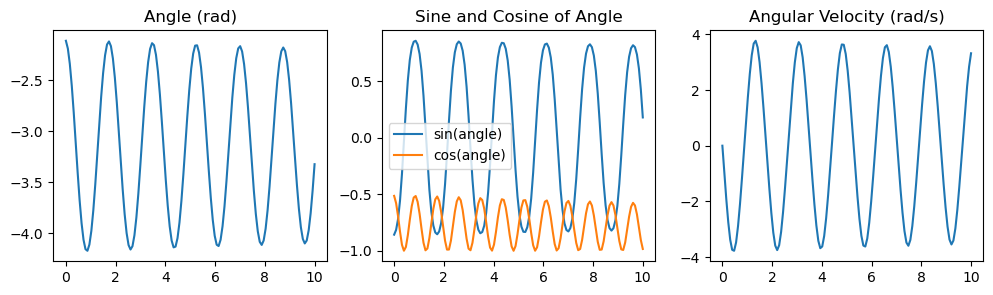

In [149]:
# look at a random trajectory
i = np.random.randint(10_000)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(times, trajs[i, 0], label='angle')
ax[0].set_title('Angle (rad)')

ax[1].plot(times, X[i, 0], label='sin(angle)')
ax[1].plot(times, X[i, 1], label='cos(angle)')
ax[1].set_title('Sine and Cosine of Angle')
ax[1].legend()

ax[2].plot(times, trajs[i, 1], label='angular velocity')
ax[2].set_title('Angular Velocity (rad/s)');

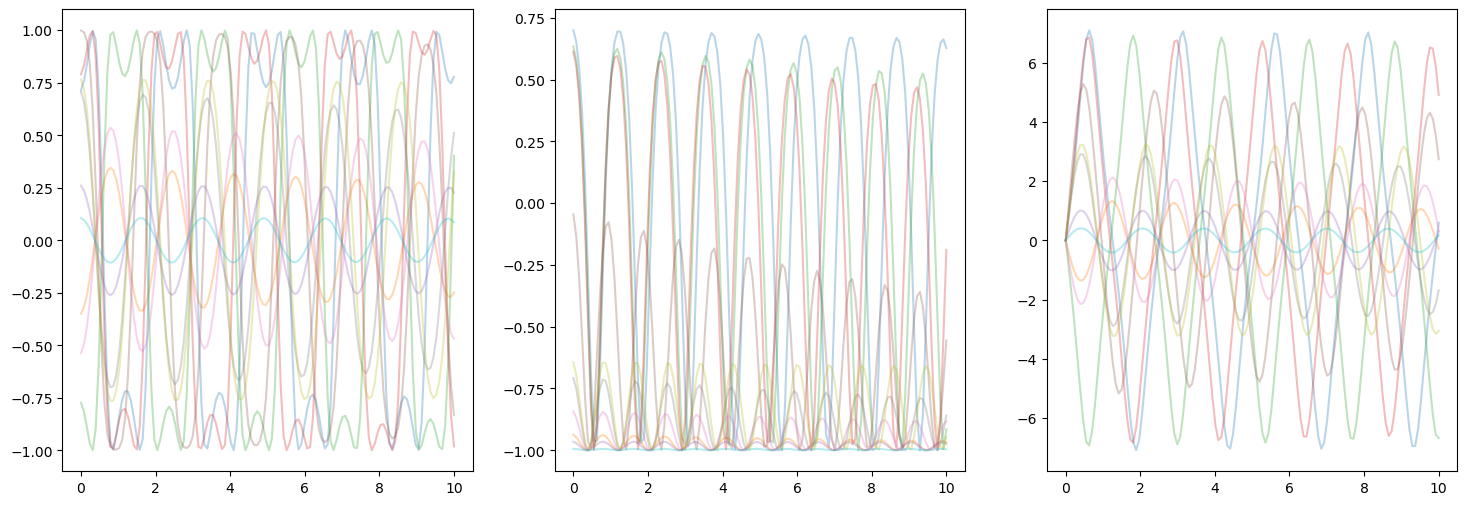

In [154]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for i in range(10):
    ax[0].plot(times, X[i, 0], alpha=0.3)
    ax[1].plot(times, X[i, 1], alpha=0.3)
    ax[2].plot(times, X[i, 2], alpha=0.3)

## Defining the VAE

In [68]:
def reparameterize(mean, logvar):
    "Reparameterization trick"
    std = torch.exp(0.5 * logvar)
    eps = torch.randn(logvar.shape).to(mean.device)
    return mean + eps * std

def kl_divergence(mean, logvar):
    "KL divergence between N(mean,var) and N(0,1)."
    return 0.5 * torch.sum(torch.square(mean) + torch.exp(logvar) - 1 - logvar, dim=-1)

In [69]:
class Encoder(nn.Module):
    def __init__(self, chan, length, n_layers, n_latents):
        super(Encoder, self).__init__()

        self.convs = nn.Sequential()
        in_channel = chan
        for i in range(n_layers):  # each layer doubles number of channels and halves input length
            out_channel = 2 * in_channel
            layer = [
                nn.Conv1d(in_channels=in_channel, out_channels=out_channel, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm1d(out_channel),
            ]
            if i < n_layers - 1: # only add ReLU if it's not the last layer
                layer.append(nn.ReLU(inplace=True))

            self.convs.append(
                nn.Sequential(*layer)
            )
            in_channel *= 2

        self.fc_mean = nn.Linear(chan * length, n_latents)
        self.fc_logvar = nn.Linear(chan * length, n_latents)

    def forward(self, x):
        x = self.convs(x)
        x = x.view(x.size(0), -1)
        mean = self.fc_mean(x)
        logvar = self.fc_logvar(x)
        return mean, logvar

In [70]:
class Decoder(nn.Module):
    def __init__(self, chan, length, n_layers, n_latents):
        super(Decoder, self).__init__()
        self.chan = chan
        self.length = length

        self.fc = nn.Linear(n_latents, chan * length)
        self.input_channel = chan * 2 ** n_layers

        self.deconvs = nn.Sequential()
        in_channel = self.input_channel
        for i in range(n_layers):  # each layer halves number of channels and doubles input length
            out_channel = in_channel // 2
            layer = [
                nn.ConvTranspose1d(in_channels=in_channel, out_channels=out_channel, kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.BatchNorm1d(out_channel),
            ]
            if i < n_layers - 1: # only add ReLU if it's not the last layer
                layer.append(nn.ReLU(inplace=True))

            self.deconvs.append(
                nn.Sequential(*layer)
            )
            in_channel //= 2

    def forward(self, z):
        "z: (bs, n_latents)"
        x = self.fc(z)
        x = x.view(x.size(0), self.input_channel, -1)
        x = self.deconvs(x)
        return x

In [71]:
class VAE(nn.Module):
    def __init__(self, chan, length, n_layers, n_latents=2):
        super(VAE, self).__init__()
        self.length = length
        self.encoder = Encoder(chan, length, n_layers, n_latents)
        self.decoder = Decoder(chan, length, n_layers, n_latents)

    def forward(self, x):
        mean, logvar = self.encoder(x)
        z = reparameterize(mean, logvar)
        x_rec = self.decoder(z)
        return x_rec, mean, logvar

## Training

In [155]:
bs = 256 * 2
X_tr, X_val = random_split(torch.tensor(X), [.7, .3])
dl_tr = DataLoader(X_tr, batch_size=bs, shuffle=True)
dl_val = DataLoader(X_val, batch_size=bs, shuffle=True)

In [243]:
model = VAE(3, 128, 3, 2).to(device)
opt = torch.optim.Adam(model.parameters(), lr=4e-3)

sum(p.numel() for p in model.parameters() if p.requires_grad)

5149

In [244]:
beta = .2  # KL divergence weight
n_epochs = 200
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # train
    model.train()
    train_loss = 0.

    for batch_idx, x in enumerate(dl_tr):
        x = x.to(device)
        x_rec, mean, logvar = model(x)
        loss = F.mse_loss(x_rec, x) + beta * kl_divergence(mean, logvar).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item() * x.size(0)

    # validation
    model.eval()
    val_loss = 0.

    for batch_idx, x in enumerate(dl_val):
        x = x.to(device)
        with torch.no_grad():
            x_rec, mean, logvar = model(x)
            loss = F.mse_loss(x_rec, x) + beta * kl_divergence(mean, logvar).mean()

        val_loss += loss.item() * x.size(0)

    train_loss /= len(dl_tr.dataset)
    val_loss /= len(dl_val.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Tr Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}')

Epoch [10/200], Tr Loss: 2.8609 Val Loss: 2.8502
Epoch [20/200], Tr Loss: 2.2392 Val Loss: 2.2214
Epoch [30/200], Tr Loss: 1.9689 Val Loss: 1.9624
Epoch [40/200], Tr Loss: 1.8652 Val Loss: 1.8783
Epoch [50/200], Tr Loss: 1.7982 Val Loss: 1.8202
Epoch [60/200], Tr Loss: 1.7440 Val Loss: 1.7602
Epoch [70/200], Tr Loss: 1.7167 Val Loss: 1.7628
Epoch [80/200], Tr Loss: 1.6974 Val Loss: 1.7387
Epoch [90/200], Tr Loss: 1.6738 Val Loss: 1.7055
Epoch [100/200], Tr Loss: 1.6639 Val Loss: 1.7085
Epoch [110/200], Tr Loss: 1.6524 Val Loss: 1.6983
Epoch [120/200], Tr Loss: 1.6569 Val Loss: 1.7194
Epoch [130/200], Tr Loss: 1.6322 Val Loss: 1.6833
Epoch [140/200], Tr Loss: 1.6257 Val Loss: 1.6806
Epoch [150/200], Tr Loss: 1.6156 Val Loss: 1.6657
Epoch [160/200], Tr Loss: 1.6048 Val Loss: 1.6772
Epoch [170/200], Tr Loss: 1.6050 Val Loss: 1.6465
Epoch [180/200], Tr Loss: 1.5814 Val Loss: 1.6101
Epoch [190/200], Tr Loss: 1.5893 Val Loss: 1.6129
Epoch [200/200], Tr Loss: 1.5773 Val Loss: 1.6412


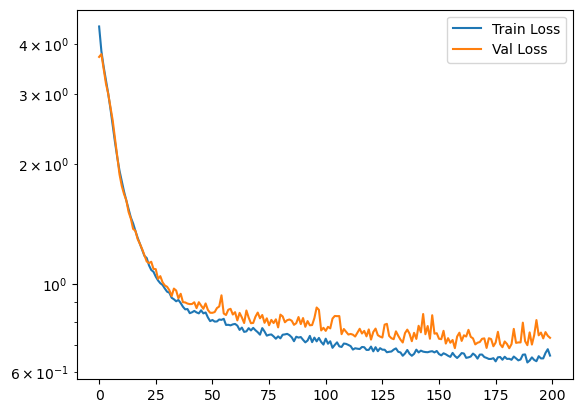

In [158]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.yscale('log')
plt.legend()

In [ ]:
save_path = 'vae.pth'
if not os.path.exists(save_path):
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to '{save_path}'")
else:
    print(f"Model already exists at '{save_path}'; not overwriting.")

Model already exists at 'vae.pth'; not overwriting.


## Inspecting the latents

In [ ]:
# load if needed
model = VAE(latent_dim=2)
model.load_state_dict(torch.load('vae.pth'))

<All keys matched successfully>

In [159]:
model.eval()
model.to('cpu');

In [160]:
with torch.no_grad():
    mean, logvar = model.encoder(torch.tensor(X))
latents = reparameterize(mean, logvar).numpy()

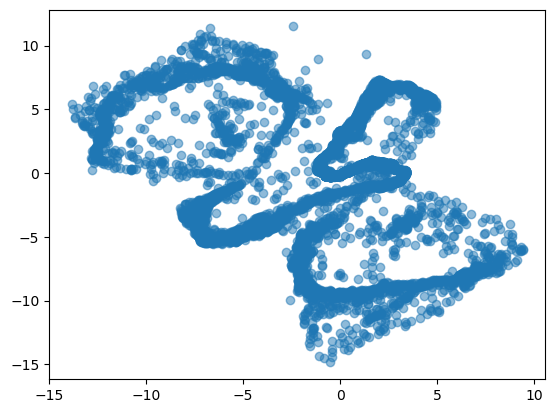

In [161]:
plt.scatter(*latents.T, alpha=0.5)

In [162]:
from latent_app import create_dash_app

app = create_dash_app(latents, trajs[:, 0])
app.run()

## Looking at some trajectories

In [163]:
from cd_poly.cd_poly import *

In [164]:
p = CDPolynomial(latents, degree=4)
alpha = p(latents).max()

In [240]:
# an ood trajectory
_, traj_ood = gen_one_traj(10., 128, np.pi/4, 7., 0.8)

with torch.no_grad():
    _, mean_ood, logvar_ood = model(torch.tensor(to_sincos(traj_ood)))
    latents_ood = reparameterize(mean_ood, logvar_ood).numpy()
mean_ood, torch.exp(0.5 * logvar_ood) # mean and std

(tensor([[-1.0724,  1.3966]]), tensor([[2.3982, 1.5465]]))

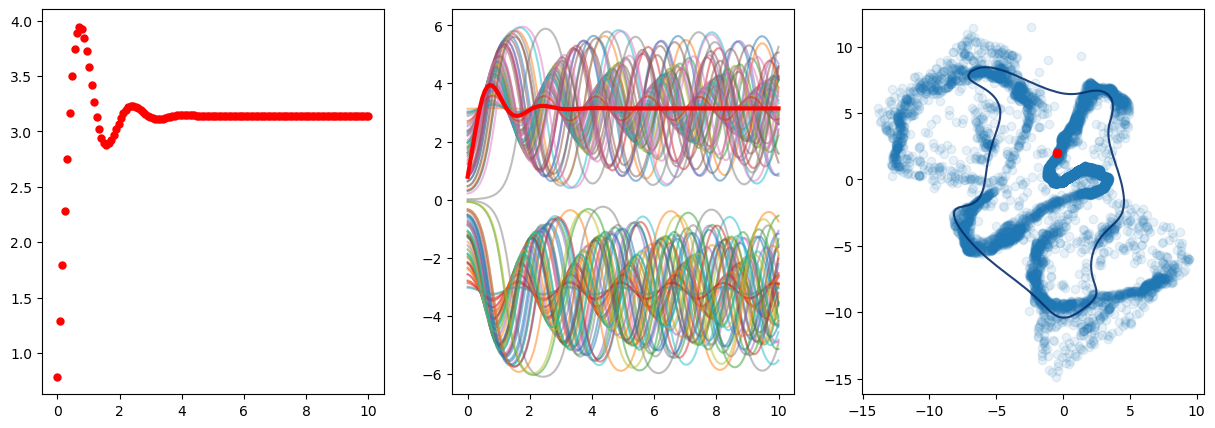

In [241]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].scatter(times, traj_ood[0, 0], color='red', lw=3, marker='.')
for i in range(100):
    ax[1].plot(times, trajs[i, 0], alpha=.5)
ax[1].plot(times, traj_ood[0, 0], color='red', lw=3)
ax[2].scatter(*latents.T, alpha=.1)
ax[2].scatter(*latents_ood.T, color='red')
plot_level_set(p, alpha * 2 ** -5, ax[2])

LinAlgError: Matrix is not positive definite

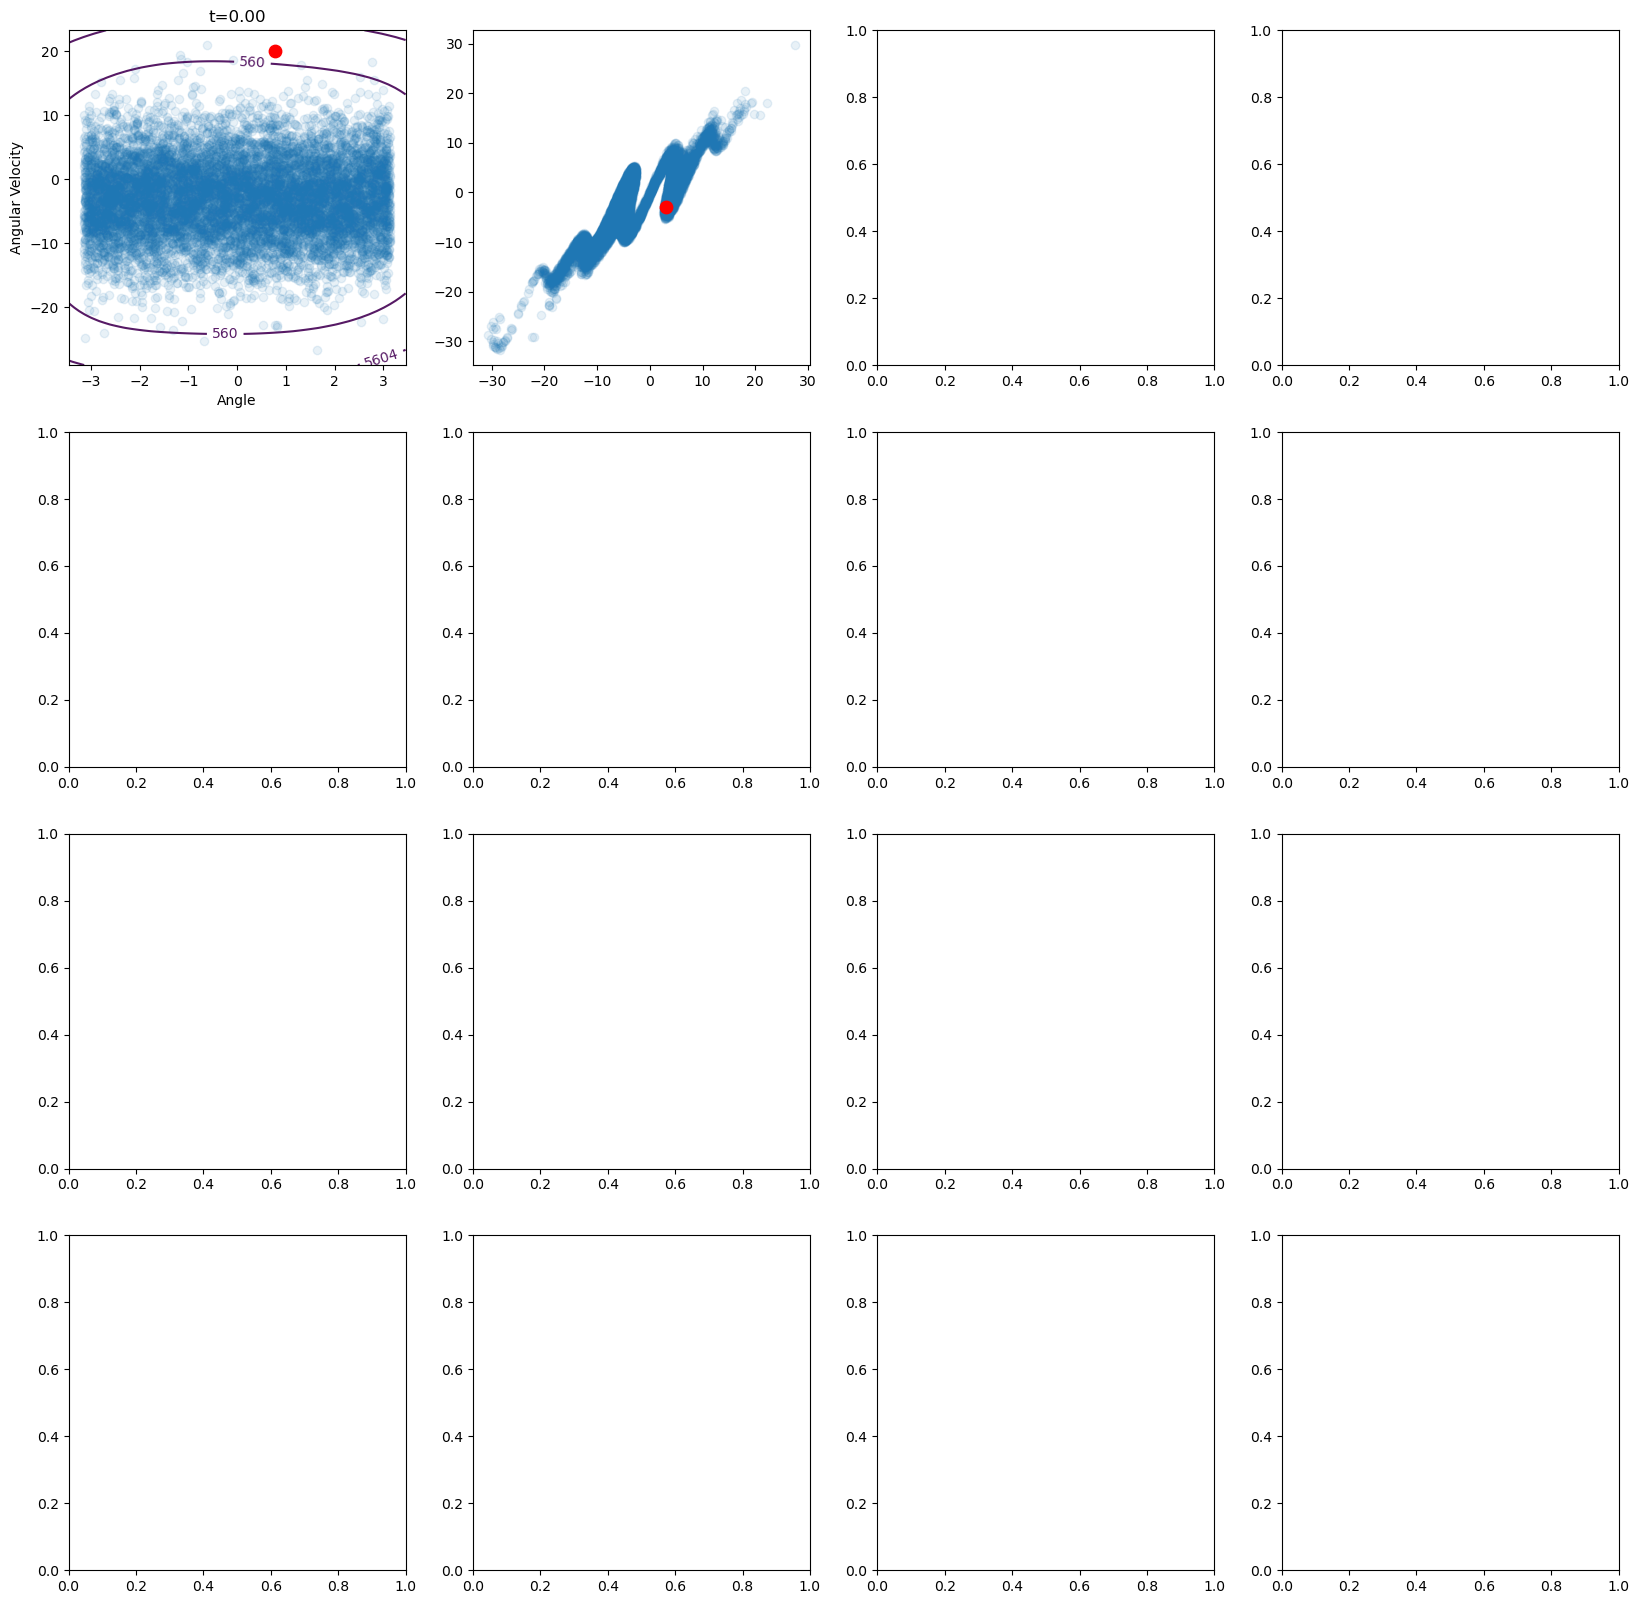

In [31]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for i in range(4):
    for j in range(4):
        times_idx = 16 * i + 4 * j
        ax[i, j].scatter(trajs[:, 0, times_idx], trajs[:, 1, times_idx], alpha=.1)
        ax[i, j].scatter(traj_ood[0, 0, times_idx], traj_ood[0, 1, times_idx], color='red', s=80)
        
        q = CDPolynomial(trajs[:, :, times_idx], degree=4, eps=7e-1)
        q.plot(ax[i, j], multiplier=0.3)

        ax[i, j].set_xlabel('Angle')
        ax[i, j].set_ylabel('Angular Velocity')
        ax[i, j].set_title(f't={times[times_idx]:.2f}')

In [32]:
# a custom trajectory
amp = 10.5
freq = 30.
const = 3.
custom = np.array([amp * np.sin(freq * times) + const * times, amp * freq * np.cos(freq * times) + const]).reshape(1, 2, -1)

with torch.no_grad():
    _, mean_custom, logvar_custom = model(torch.tensor(to_sincos(custom)))
    latents_custom = reparameterize(mean_custom, logvar_custom).numpy()
latents_custom

array([[127.383446 ,   1.5447221]], dtype=float32)

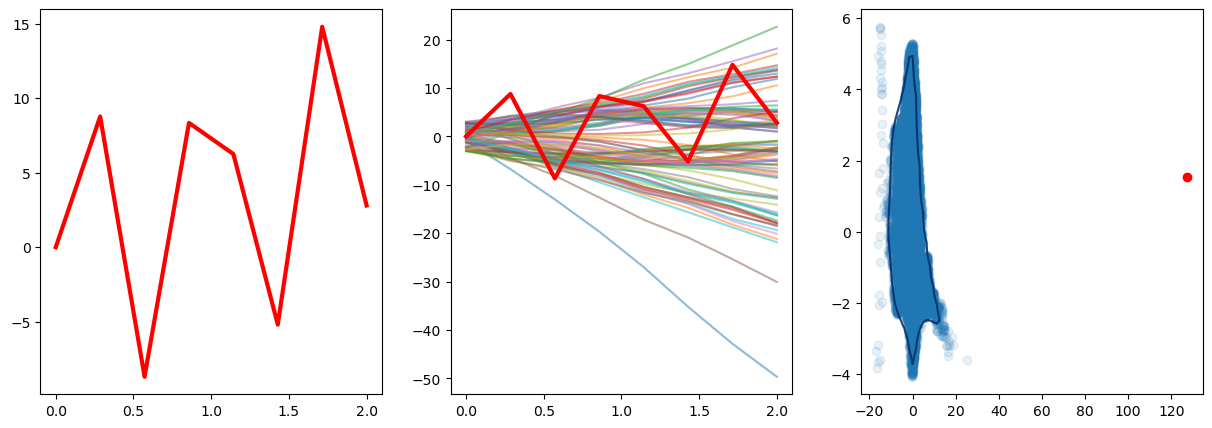

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(times, custom[0, 0], color='red', lw=3)
for i in range(100):
    ax[1].plot(times, trajs[i, 0], alpha=.5)
ax[1].plot(times, custom[0, 0], color='red', lw=3)
ax[2].scatter(*latents.T, alpha=.1)
ax[2].scatter(*latents_custom.T, color='red')
plot_level_set(p, alpha * 6e-3, ax[2])

Doesn't work - some very ood trajectories are being classified as such

Interesting - with higher training loss, the latents were better at identifying ood

The feature detection isn't good - higher frequency or damped trajectories get similar outputs to regular trajectories

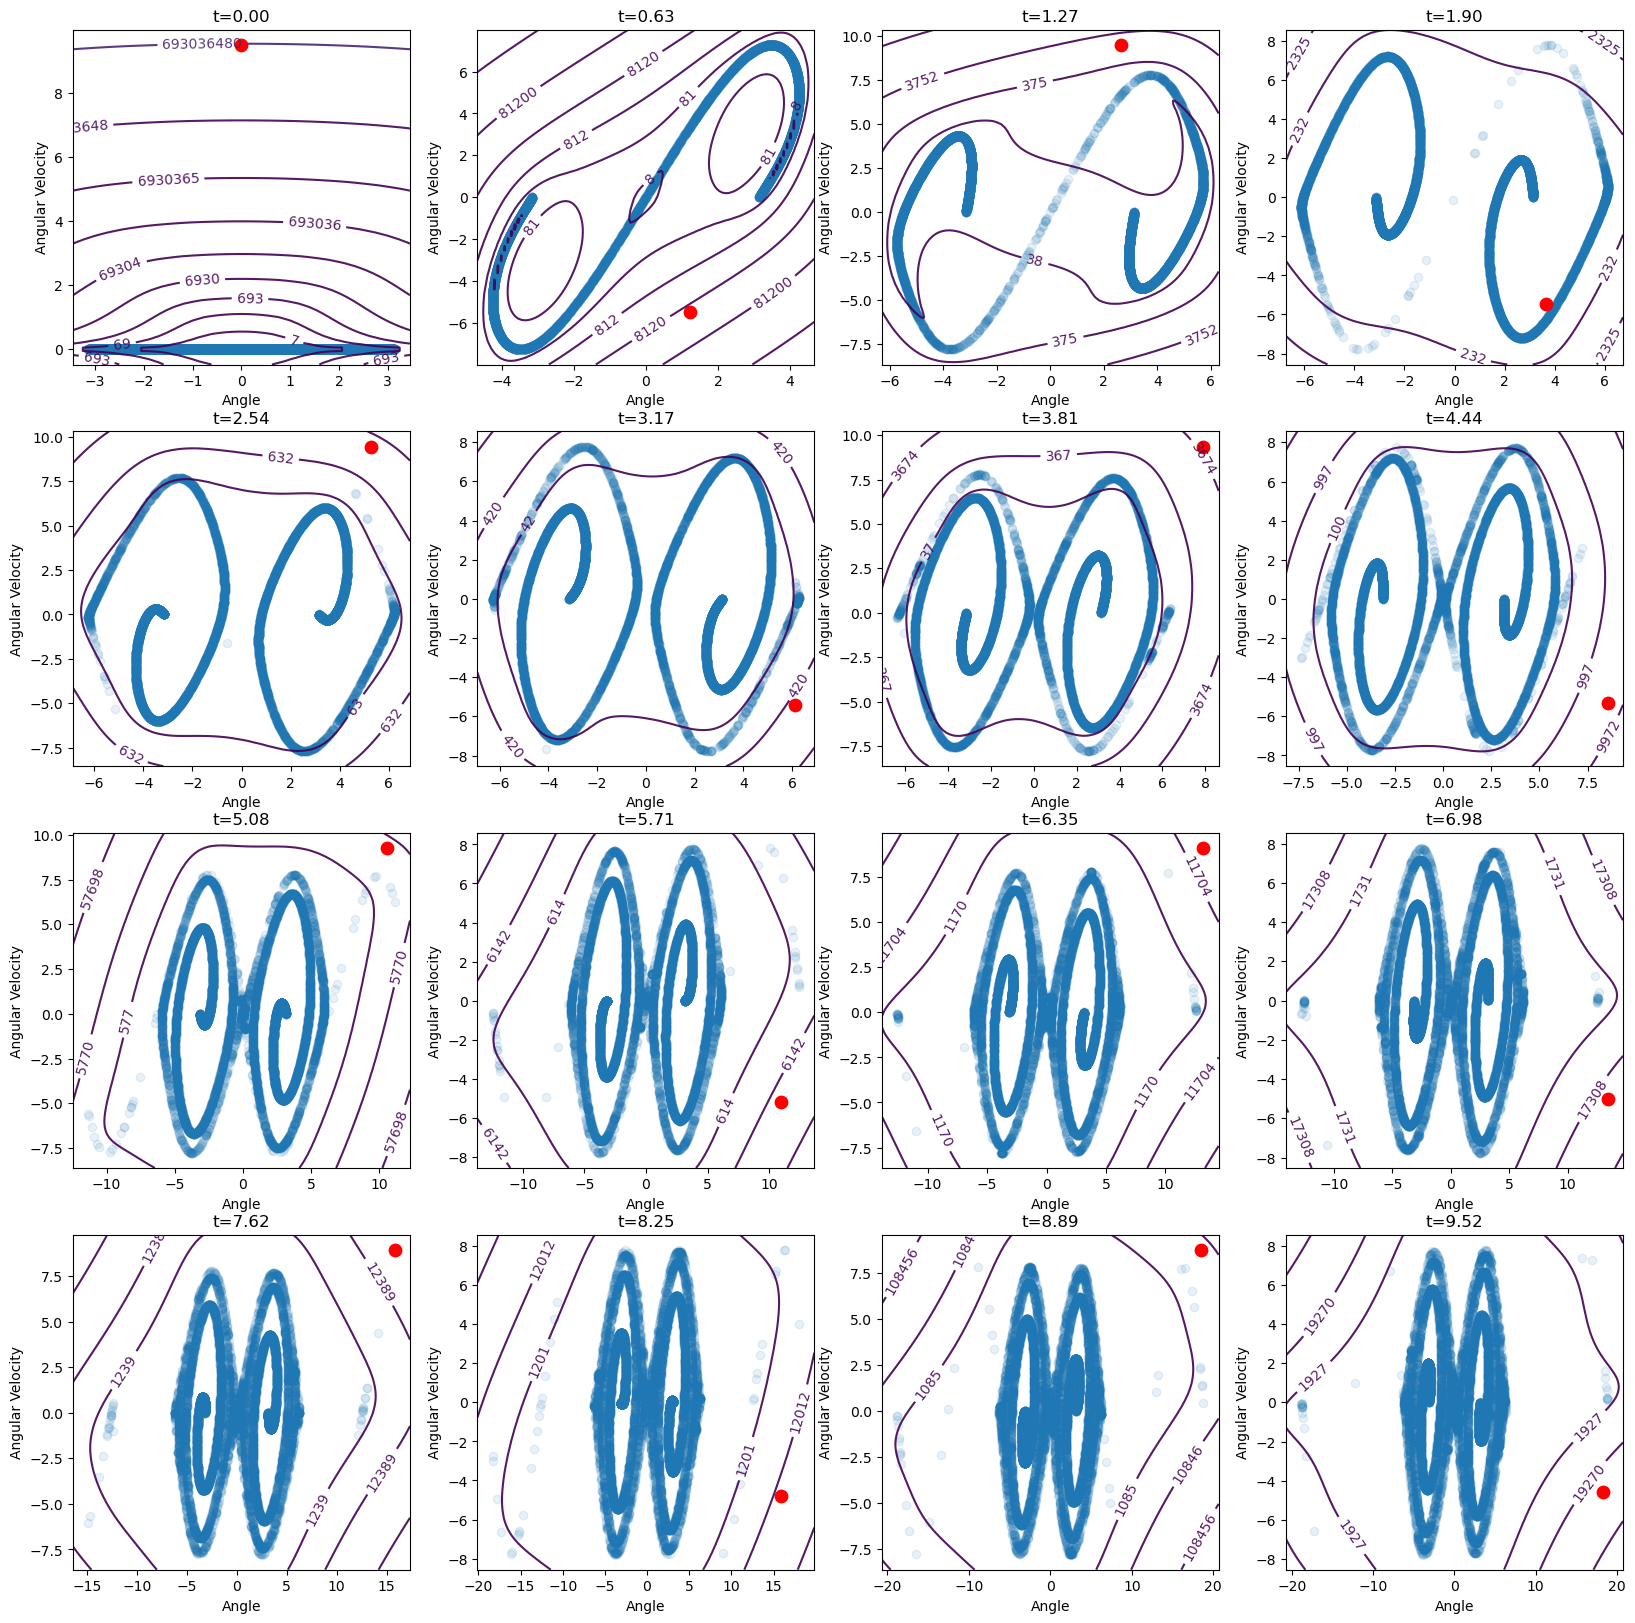

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for i in range(4):
    for j in range(4):
        times_idx = 16 * i + 4 * j
        ax[i, j].scatter(trajs[:, 0, times_idx], trajs[:, 1, times_idx], alpha=.1)
        ax[i, j].scatter(custom[0, 0, times_idx], custom[0, 1, times_idx], color='red', s=80)
        
        q = CDPolynomial(trajs[:, :, times_idx], degree=4, eps=1e-1)
        q.plot(ax[i, j], multiplier=0.3)

        ax[i, j].set_xlabel('Angle')
        ax[i, j].set_ylabel('Angular Velocity')
        ax[i, j].set_title(f't={times[times_idx]:.2f}')

## Comparing a "safe" distribution to "unsafe" distribution

In [170]:
def plot_dist_latents(model, param_dists, ax, **kwargs):
    "Plot the latents of trajectores generated from the distributions, according to the model."
    _, trajs = gen_trajs(10_000, 2., model.length, param_dists)
    X = to_sincos(trajs)
    with torch.no_grad():
        mean, logvar = model.encoder(torch.tensor(X))
        latents = reparameterize(mean, logvar).numpy()
    ax.scatter(*latents.T, alpha=0.2, **kwargs)

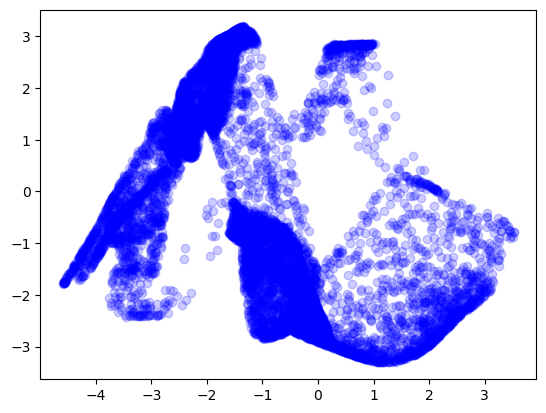

In [171]:
fig, ax = plt.subplots()
safe_dist = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.uniform(-3., 6.),
    'b': stats.uniform(0., 0.)
}
unsafe_dist = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.uniform(10., 2.),
    'b': stats.uniform(.7, .5)
}

#plot_dist_latents(model, unsafe_dist, ax, color='red', label='Unsafe Distribution')
plot_dist_latents(model, safe_dist, ax, color='blue', label='Safe Distribution')